![logo](./figures/LogoLine_horizon_C3S.png)

# Tutorial on climate stripes

The simple and easy-to-use climate stripes were proposed by Ed Hawkins in 2018. This minimalist design, which omits axes and numbers and uses only colours, communicates a clear message about rising temperatures caused by climate change. 

In this tutorial we will compute climate stripes for the Mediterranean region. First, we demonstrate how to create such climate stripes for climate monitoring based on the ERA5 global reanalysis, based on the ERA5 monthly data available through the [CDS ERA5 monthly catalogue](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-monthly-means?tab=overview). Then, we show how climate stripes can be computed using global climate models, covering not only past but also future periods. Global climate model data are retrieved from the [C3S Atlas Dataset](https://cds.climate.copernicus.eu/datasets/multi-origin-c3s-atlas?tab=overview), where datasets for a collection of models can be easily downloaded at a common temporal and spatial resolution.

## Download and prepare the data
Before starting, we need to prepare the environment. This includes two steps: 1) Installing the CDS API, 2) Importing the specific python libraries we will use.
### Install CDS API
To download the data, we will use `CDS API` (Application Programming Interface). This allows users to automate downloads and data retrievals using `Python` scripts instead of manually browsing at the website (https://cds.climate.copernicus.eu/). It lets you select specific data, variables, and time ranges, making it possible to efficiently download large volumes of climate information for research or analysis.
To install the `CDS API`, run the following command.

In [ ]:
!pip install cdsapi

### Import libraries

Python libraries are collections of pre-written code (functions, modules, classes) that provide ready-to-use solutions for specific tasks without writing everything from scratch.

In climate science, we mostly work with data in `NetCDF` format. To best handle this type of data efficiently, we will use libraries designed for working with labelled multi-dimensional arrays, in particular `Xarray`. Additionally, we use `NumPy`, which supports large multi-dimensional arrays and provides a large collection of high-level mathematical functions to operate on these arrays. For plotting and visualising data, we will use `Matplotlib`. Warnings related to data downloads via the `CDS API` (e.g., server security, connection issues, download size, or data availability) are disabled using `urllib3`. Finally, the `glob` and `zipfile` modules are imported to search for and extract files, respectively.

In [79]:
# CDS API
import cdsapi

# Libraries for working with multi-dimensional arrays
import numpy as np
import xarray as xr

# Libraries for plotting and visualising data
import matplotlib.path as mpath
import matplotlib.pyplot as plt

# Disable warnings for data download via API
import urllib3 
urllib3.disable_warnings()

# Search for files and directories using patterns
from glob import glob

# Extract zipfile
import zipfile 

## Enter your CDS API key

We will request data from the CDS programmatically with the help of the CDS API.
To set up the CDS API credentials, we need to define two variables: `URL` and `KEY`. These can be obtained by registering and login to the CDS (https://cds.climate.copernicus.eu), and following the instructions at https://cds.climate.copernicus.eu/how-to-api

In [80]:
URL = 'https://cds.climate.copernicus.eu/api'
KEY = ''

Next, we specify a data directory in which we will download our data and all output files that we will generate:

In [81]:
DATADIR = './'

## Download ERA5 global reanalysis data

To search for data, visit the CDS website: https://cds.climate.copernicus.eu/. There, you can look for ECMWF ERA5 global reanalysis data using the search bar (https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-monthly-means?tab=overview). ERA5 is the 5th generation of the ECMWF Reanalysis dataset. Reanalysis uses a state-of-the-art forecast model and data assimilation system to create a consistent “map without gaps” over the past decades. The climatic variable we use for evaluating the climate stripes is the 2m air temperature from 1940 to 2025 for the Mediterranean region.

After selecting the correct catalogue entry (ERA5), we need to specify which variables, as well as temporal and geographic coverage, we are interested in. These can all be selected in the “Download data” tab. In this tab, a form appears in which we will choose the following parameters to download:

**Variable:** `2m temperature`\
**Temporal Resolution:** `Monthly` \
**Year:** `1940 to 2025` \
**Month:** `all (use “Select all” button)`\
**Geographical area:** `Mediterranean region [45, -10, 30, 40]`\
**Format:** `NetCDF (.nc)`

At the bottom of the download form, select "Show API request". This will reveal a block of code that you can simply copy and paste into a cell in your Jupyter Notebook. Running the cell will retrieve and download the requested data to your local directory. The download may take a few minutes.
Note that the terms and conditions of this particular dataset need to have been accepted in the CDS. The option to view and accept these conditions is provided just above the “Show API request” option.

In [ ]:
c = cdsapi.Client(url=URL, key=KEY)
c.retrieve(
    'reanalysis-era5-single-levels-monthly-means',
    {
        'product_type': 'monthly_averaged_reanalysis',
        'variable': '2m_temperature',
        'year': [
             "1940", "1941", "1942",
             "1943", "1944", "1945",
             "1946", "1947", "1948",
             "1949", "1950", "1951",
             "1952", "1953", "1954",
             "1955", "1956", "1957",
             "1958", "1959", "1960",
             "1961", "1962", "1963",
             "1964", "1965", "1966",
             "1967", "1968", "1969",
             "1970", "1971", "1972",
             "1973", "1974", "1975",
             "1976", "1977", "1978",
             "1979", "1980", "1981",
             "1982", "1983", "1984",
             "1985", "1986", "1987",
             "1988", "1989", "1990",
             "1991", "1992", "1993",
             "1994", "1995", "1996",
             "1997", "1998", "1999",
             "2000", "2001", "2002",
             "2003", "2004", "2005",
             "2006", "2007", "2008",
             "2009", "2010", "2011",
             "2012", "2013", "2014",
             "2015", "2016", "2017",
             "2018", "2019", "2020",
             "2021", "2022", "2023",
             "2024", "2025",
        ],
        'month': [
            '01', '02', '03',
            '04', '05', '06',
            '07', '08', '09',
            '10', '11', '12'],
        
        'time': ['00:00', '12:00'],
        'area': [45, -10, 30, 40],
        
        'data_format': 'netcdf_legacy',
    },
    f'{DATADIR}era5_monthly_t2m_med.nc')

## Data processing
### Open and prepare the data

First of all, we will inspect the data. In order to do so, we make use of the Xarray library to open the NetCDF file as an `xarray.Dataset` by using the `open_dataset()` function.
The `xarray.Dataset` contains one data variable (`t2m`) with dimensions: latitude and longitude with 61 and 260 points, respectively (0.25°x0.25° resolution), 1032 time points (86 years * 12 months), and 2 `expver` (representing two different experiment versions of the data, a dimension that is available when the most recent months are still not consolidated). It also contains the coordinates, which describe the dimensions by providing the actual values associated with them.

Also, Xarray introduces indexes, which are internal structures (typically based on pandas) that enable efficient access and selection of coordinate values. Finally, attributes provide descriptive metadata, including units, variable descriptions, and information about the data source or experiment. In this case, the attributes indicate that the CDS automatically converts the original data from GRIB format to NetCDF on the server. This occurs because we have specified in the request that the data should be downloaded in `.nc` format.

In [82]:
# Create Xarray Dataset
ds_ERA5 = xr.open_dataset(f'{DATADIR}era5_monthly_t2m_med.nc')
ds_ERA5

<xarray.Dataset> Size: 101MB
Dimensions:    (time: 1032, latitude: 61, longitude: 201)
Coordinates:
  * longitude  (longitude) float32 804B -10.0 -9.75 -9.5 ... 39.5 39.75 40.0
  * latitude   (latitude) float32 244B 45.0 44.75 44.5 44.25 ... 30.5 30.25 30.0
  * time       (time) datetime64[ns] 8kB 1940-01-01 1940-02-01 ... 2025-12-01
Data variables:
    t2m        (time, latitude, longitude) float64 101MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2026-07-15 11:42:56 GMT by grib_to_netcdf-2.42.0: grib_to_n...

Next, we convert the Xarray dataset which may contain multiple variables, into an Xarray DataArray, which only holds a single multi-dimensional variable along with its coordinates. 

Next, `expver` coordinate is selected. This coordinate distinguishes between different versions of the same dataset: in ERA5, 1 corresponds to the final (consolidated) data, and 5 to provisional (near real-time) data.

Note that the ERA5 temperature data are in units of Kelvin, in the International System of Units (SI) for temperature. To convert the values from Kelvin to degrees Celsius, you need to subtract 273.15 from each value. Since the unit has changed, we then assign a new `unit` attribute using the `attrs` property.

In [83]:
# Create Xarray Data Array
t = ds_ERA5['t2m']

# Select the consolidated data (expver = 1)
if "expver" in t.dims:
    t = t.sel(expver=1)

# Modify Units
t = t - 273.15
t.attrs['units'] = '° C'

### Compute anomalies

To generate climate stripes for the Mediterranean mean temperature, we first temporally aggregate the data to yearly resolution by computing annual mean values. We then spatially average the results over the Mediterranean domain. Spatial aggregation requires averaging over both latitude and longitude; however, grid cells do not represent equal surface areas, since each grid point corresponds to a different area depending on its latitude. This must therefore be taken into account when computing the averages. One common approach is to use the cosine of latitude as a weighting factor to approximate variations in grid-cell area.

First, we compute the required weights using the cosine of latitude. Then, we compute a weighted mean of temperature by multiplying the temperature data by the weights and dividing by the mean of the weights. This can be done in two different ways: (1) directly by applying the formulation, or (2) using a specific Xarray function designed for this purpose:

In [84]:
# Calculate weights
weights = np.cos(np.deg2rad(t.latitude))

# Aggregate over the Mediterranean region
# Option 1 (direct approach):
t_weighted = (t * weights).mean(dim=("latitude", "longitude"),  keep_attrs=True) / weights.mean()

# Option 2 (using xarray funtion):
t_weighted = t.weighted(weights).mean(dim=("latitude", "longitude"),  keep_attrs=True)

# Assign Attributes
t_weighted = t_weighted.assign_attrs(t.attrs)
t_weighted.attrs['units'] = '° C'

We will now inspect the anomaly of the different years with respect to the climate normal (the mean of at least 30 years of data). The term anomaly refers to the deviation of a value from the long-term average. Positive or negative anomalies indicate that the average temperature of a particular year was respectively warmer or cooler than the reference long-term mean.

The annual anomalies of the Mediterranean temperature time series are computed by subtracting the climatology of the entire period or thirty-year period from it. We considered one of the WMO 30-year reference period (1961-1990) for the climate mean. It is important to note that grouping by `time.year` creates a new `year` dimension. The coordinates of this dimension correspond to individual calendar years, and the associated values are the annual means computed for each year.

In [85]:
# Group by year
t_mean = t_weighted.groupby('time.year').mean(keep_attrs=True)

# Compute the Climatology
clim_era5 = t_mean.sel(year=slice('1961-01-01', '1990-12-01'))
clim_era5 = clim_era5.mean(dim="year", keep_attrs=True)

# Compute the Anomaly and Keep Attributes
anom_t = t_mean - clim_era5

## Plot
### Preparation of the data

Before visualizing the climate stripes, some additional data preparations are needed. The Mediterranean temperature anomalies values are organized in a time series with a single dimension (`time`). However, two-dimensional arrays are needed for plotting with the function `pcolormesh()`. It is important to keep in mind that `pcolormesh()` draws a grid of rectangular “cells” to visualize 2D data. For this reason, the coordinates must have at least two values (because if there were only one, Matplotlib would not be able to draw a rectangle in that direction). In other words, each cell requires both a height and a width, and a single value does not define a vertical range.

To achieve this, an extra axis is added to the temperature anomalies array. Similarly, we generate a vertical coordinate [y] with length 2.

The horizontal coordinate will be the time vector. The latter was modified to indicate the time interval edges rather than the interval centers. This ensures the year labels appear at the center of each vertical bar, instead of at the beginning.

In [86]:
# Adding an extra axis
Z = anom_t.values[:, np.newaxis]   # (time, 1)

# Vertical coordinate
y = [0, 1]

# Horizontal coordinate
time = anom_t["year"].values

# Building temporal borders
dt = np.diff(time) / 2
time = np.concatenate(([time[0] - dt[0]], time[:-1] + dt, [time[-1] + dt[-1]]))

Finally, maximum and minimum values of the time series are identified and used to define the limits of the colorbar.

In [87]:
# Defining limits
max_values = Z.max()
min_values = Z.min()
if abs(max_values)<=abs(min_values):
    max_values=-min_values
else:
    min_values=-max_values

### Plotting the climate stripes
The climate stripes figure displayed below shows the near-surface temperature anomaly from 1940 to 2025 for the ERA5 reanalysis data. The anomaly is computed with respect to a recent reference climatological period, namely 1961-1990. 

A clear positive trend is observed in the data, with temperatures shifting from negative anomalies during the 20th century to increasingly positive anomalies up to the present.

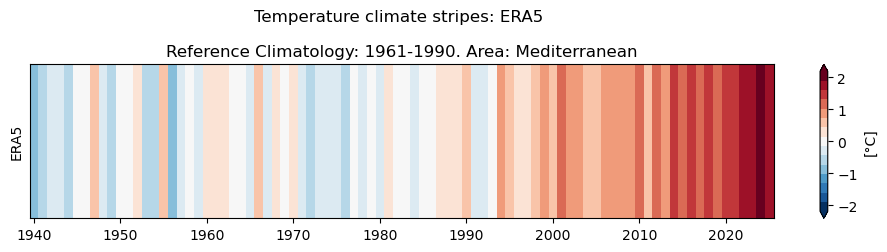

In [88]:
# Colorbar: colors and number of colors
cmap = plt.get_cmap("RdBu_r", 15)

# Figure
fig, ax = plt.subplots(figsize=(12, 2)) # Figure size

img = ax.pcolormesh(
    time,
    y,
    Z.transpose(),
    cmap=cmap,
    vmin=min_values,
    vmax=max_values,
    shading="flat"
)
ax.set_yticks([])

# Add colorbar
cbar = fig.colorbar(img,ax=ax, extend='both')
cbar.set_label("[°C]")

# Axis
plt.title("Temperature climate stripes: ERA5 \n\nReference Climatology: 1961-1990. Area: Mediterranean")
plt.ylabel("ERA5")
plt.show()

## Climate simulations: historical and future Projections

Next, we repeat the analysis using climate projections. Particularly, we will use the datasets (https://cds.climate.copernicus.eu/datasets/multi-origin-c3s-atlas) used for the Copernicus Climate Change Service (C3S) Atlas https://atlas.climate.copernicus.eu/atlas and try to reproduce their results and figures.

### Download C3S Atlas data 

To search for C3S Atlas data, visit the CDS website: https://cds.climate.copernicus.eu/datasets/multi-origin-c3s-atlas?tab=download. The C3S Atlas collects several databases encompassing observations, reanalysis and climate projections at both global and regional scales. In this work, we will focus on the CMIP6 global climate model projections, which corresponds to the 6th phase of the Coupled-Model Intercomparison Project. 

The variable used to generate the climate stripes is the 'Monthly temperature' (averaged from daily mean near-surface/2-metre air temperature) covering the period from 1850 to 2100 for the Mediterranean region. 
Although this full time span is not provided by a single CMIP6 experiment, it can be obtained by combining two experiments: historical and scenario (SSP5-8.5 in our case). 

The historical experiment simulates the climate conditions from 1850 to 2014, and characterizes the recent past climate. To investigate the potential future climate, several long-term climate projections experiments simulate the evolution of the climate system from 2015 to 2100 under different (radiative forcing and socio-economic) assumptions. Among the available family of scenarios, we consider the SSP5-8.5 experiment, which presents one of the largest anthropogenic climate change signals emerging from the background of natural variability.
It is essential to remember that the same models must be present in both historical and scenario samples. In order to compare the simulations, the samples must contain the same number of simulations that correspond exactly to the same models.

Similarly to the reanalysis data case, after selecting the correct catalogue entry, variables, temporal and geographic coverage, the data retrieval code appears in the "Show API request" box. The data can be downloaded by simply copying the code into the Jupyter Notebook.

Running the code blocks below will download the data from the CDS as specified by the following API keywords:

**Project:** `C3S Atlas dataset`\
**Origin:** `CMIP6`\
**Variables:** `Monthly temperature`  
**Experiment:** `SSP5-8.5`  
**Year:** `1850-2014; 2015-2100`  
**Month:** `All`  
**Day:** `All`  
**Area:** `Mediterranean Sector [45, -10, 30, 40]`

In [ ]:
client = cdsapi.Client(url=URL, key=KEY)

client.retrieve(
        "multi-origin-c3s-atlas",
        {
        "origin": "cmip6",
        "experiment": "historical",
        "domain": "global",
        "period": "1850-2014",
        "variable": "monthly_temperature",
        "bias_adjustment": "no_bias_adjustment",
        "area": [45, -10, 30, 40]
         },

         f'{DATADIR}c3s_monthly_T_historical.zip')

In [ ]:
client = cdsapi.Client(url=URL, key=KEY)

client.retrieve(
        "multi-origin-c3s-atlas",
        {
    "origin": "cmip6",
    "experiment": "ssp5_8_5",
    "domain": "global",
    "period": "2015-2100",
    "variable": "monthly_temperature",
    "bias_adjustment": "no_bias_adjustment",
    "area": [45, -10, 30, 40]
         },

         f'{DATADIR}c3s_monthly_T_ssp585.zip')

#### Unzip the downloaded data files

From the CDS, CMIP6 data are available as NetCDF files compressed into zip archives. We can use the `zipfile` Python package to extract their contents. To do this, we use a loop that processes each file one by one. Inside the loop, a `ZipFile()` object is created for the current file, and all of its contents are extracted using the `extractall()` method.

In [90]:
# Extract all the .zip files in the folder
cmip6_zip_paths = glob(f'{DATADIR}*.zip')
for j in cmip6_zip_paths:
    with zipfile.ZipFile(j, 'r') as zip_ref:
        zip_ref.extractall(f'{DATADIR}')

### Data processing

#### Open the data and assign useful coordinates
Again, we make use of the Xarray library to open the NetCDF file as an xarray.Dataset by using the function `open_dataset()`. The model data presents `latitude`, `longitude`, `time` and `member` coordinates.

In [91]:
# Load data, group by 'year' and regional mean
ds_hist = xr.open_dataset(f'{DATADIR}t_CMIP6_historical_mon_18500101-20141201.nc')
ds_hist = ds_hist['t'].compute()

ds_ssp = xr.open_dataset(f'{DATADIR}t_CMIP6_ssp585_mon_20150101-21001201.nc')
ds_ssp = ds_ssp['t'].compute()

The `member` coordinate is a numerical index that indicates the number of models for the historical and SSP5-8.5 experiments. However, the dataset provides several alternative options to describe the ensemble members, depending on the intended analysis. These include:

- `member_id`: contains the full information about each model run.
- `gcm_institution`: indicates the originating institution.
- `gcm_model`: provides the model names.
- `gcm_variant`: describes the specific experiment configuration.

Since our goal is to compare the same models with the same configurations in both historical and scenario simulations, we focus on identifying the same members using the `member_id` variable.

#### Select sample
As mentioned earlier, sometimes different experiments are not performed to the same sample of models. In this case, the historical experiment has been performed on 30 models, and the scenario one only on 27. Since we are interested in long-term climate evolutions from 1850 to 2100, we identify and keep only those models which are present in both historical and scenario experiments.

In [92]:
# Identify and select common models in both experiments
common = np.intersect1d(ds_hist.member_id, ds_ssp.member_id) # identify

ds_hist = ds_hist.where(ds_hist.member_id.isin(common), drop=True)
ds_ssp  = ds_ssp.where(ds_ssp.member_id.isin(common), drop=True)

#### Data aggregation

After selecting a common sample, the variables are grouped by year and averaged over latitude and longitude, using the cosine of latitude as a proxy to account for differences in grid-cell areas. The temperature data now has member and year dimensions.

In [93]:
# Calculate weights
weights = np.cos(np.deg2rad(ds_hist.lat))

# Aggregate over the Mediterranean region using xarray funtion:
ds_hist = ds_hist.weighted(weights).mean(dim=("lat", "lon"),  keep_attrs=True)
ds_ssp = ds_ssp.weighted(weights).mean(dim=("lat", "lon"),  keep_attrs=True)

# Group by year
ds_hist = ds_hist.groupby('time.year').mean()
ds_ssp = ds_ssp.groupby('time.year').mean()

#### Compute anomalies
Once the model sample is common in both experiments, we concatenate the corresponding (historical and scenario) simulations and compute the temperature anomaly by subtracting the 1850-1900 climatology (this time we use the period 1850 to 1900 as the climate reference period).

In [94]:
# Total time-series and temperature anomaly
serie = xr.concat([ds_hist, ds_ssp], dim="year")

clim = serie.sel(year=slice('1850-01-01', '1899-12-31')).mean(dim="year", keep_attrs=True)
t_anom =  serie - clim 

### Plot
The climate stripe figure is plotted similarly to the reanalysis case, but this time the vertical coordinate will indicate the number models.

#### Define coordinates

In [95]:
# Coordinate definitions
# Vertical coordinate
y = xr.DataArray(np.arange(28), dims="member")

# Horizontal coordinate
time = t_anom["year"].values

# Temporal ticks
dt = np.diff(time) / 2
time = np.concatenate(([time[0] - dt[0]], time[:-1] + dt, [time[-1] + dt[-1]]))

#### Plotting the climate stripes
To sum up, the figure shows the historical evolution (1850–2014) and future projections (2015–2100) of the Mediterranean region near-surface temperature, simulated by a collection of CMIP6 models. The data are presented as anomalies with respect to the pre-industrial period (1850–1900). A vertical line marks the year 2015 to distinguish the past (historical scenario) from the future (SSP scenario). The generated figure can be compared with its counterpart from the C3S Atlas: https://atlas.climate.copernicus.eu/atlas/PHBFl7Sq. By clicking on the “i” icon in the upper-right corner of the C3S Atlas, users can find more information about the workflow used to generate the figures and the multi-model ensemble (provenance).

All models show a clear and positive trend, which can be summarized in two main aspects:

- Temperature exhibits both negative and positive anomalies from the beginning of the period until approximately the start of the 21st century. From that point onwards the climate signal emerges and only positive anomalies are observed.

- The magnitude of the anomalies is relatively small before the 21st century and increases progressively from this point on. It is worth noting that not all models reach the same temperature anomaly by the end of the century. This reflects differences in climate sensitivity across models, which depend on variations in model characteristics such as the representation of physical processes, climate feedbacks, or spatial resolution.

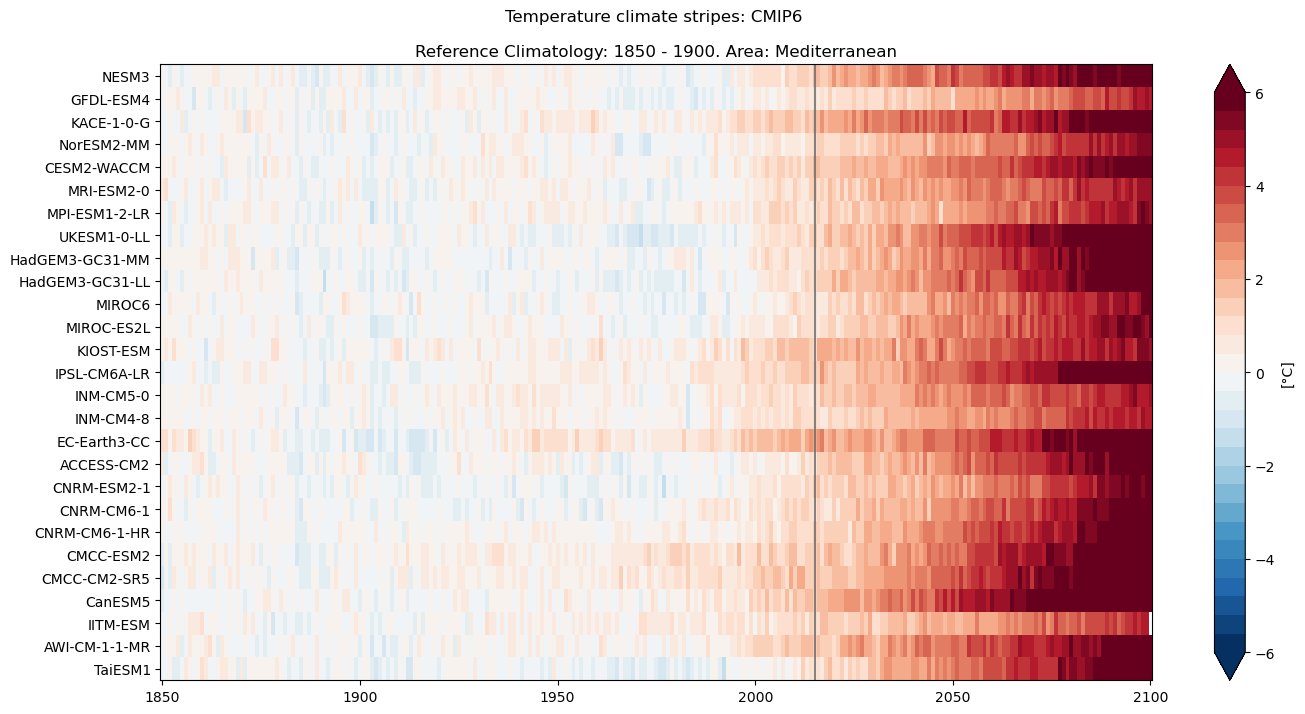

In [96]:
# Colorbar: colors and number of colors
cmap = plt.get_cmap("RdBu_r", 30)

# Figure
fig, ax = plt.subplots(figsize=(16, 8)) # Figure size

img = ax.pcolormesh(
    time,
    y,
    t_anom.transpose("member", "year"),
    cmap=cmap,
    vmin=-6,
    vmax=6,
    shading="flat"
)

# Axis
ax.set_yticks(np.arange(27)+0.5)
ax.set_yticklabels(t_anom.gcm_model.values)

ax.axvline(x=2015, color='dimgrey', linewidth=1.5, linestyle="-", alpha=0.8)

# Add colorbar
cbar = fig.colorbar(img,ax=ax, extend='both')
cbar.set_label("[°C]")

# Title
plt.title("Temperature climate stripes: CMIP6 \n\nReference Climatology: 1850 - 1900. Area: Mediterranean")

plt.show()

## Compare ERA5 against the CMIP6 multi-model median

We will now compare the CMIP6 multi-model median with the ERA5 reanalysis using the same reference period, 1961–1990, to calculate the climatological baseline for both datasets. This common reference period ensures that the temperature anomalies are calculated consistently and allows for a direct comparison between the CMIP6 simulations and the ERA5 reanalysis during the historical period.

The comparison will cover the full ERA5 period. Up to 2014, the CMIP6 data represent historical simulations, while from 2015 onwards they correspond to climate projections. ERA5, in contrast, provides a reanalysis-based estimate of the observed climate for the historical period. Therefore, the comparison after 2015 should be interpreted as an assessment of how the CMIP6 projections evolve relative to the observational reference represented by ERA5, rather than as a direct model–observation validation.

Calculate CMIP6 anomalies using the ERA5 reference period (1961–1990), compute the multi-model ensemble median, and select the common time period shared by ERA5 and CMIP6.

In [97]:
clim = serie.sel(year=slice('1961-01-01', '1990-12-01')).mean(dim="year", keep_attrs=True)
t_anom =  serie - clim 
t_anom_median = t_anom.median(dim="member")
t_anom_median_period = t_anom_median.sel(
    year=slice(
        ds_ERA5.time.dt.year[0].item(),
        ds_ERA5.time.dt.year[-1].item()
    )
)
time = list(t_anom_median_period.year.data) + [
    t_anom_median_period.year.data[-1] + 1
]

Calculate the difference between the CMIP6 multi-model median and ERA5.

In [98]:
diff_values = t_anom_median_period.data - Z.transpose()

Plot the results in two subplots. The first should show the CMIP6 multi-model median and ERA5 temperature anomalies relative to the 1961–1990 reference period, while the second should show the difference between these two anomaly time series.

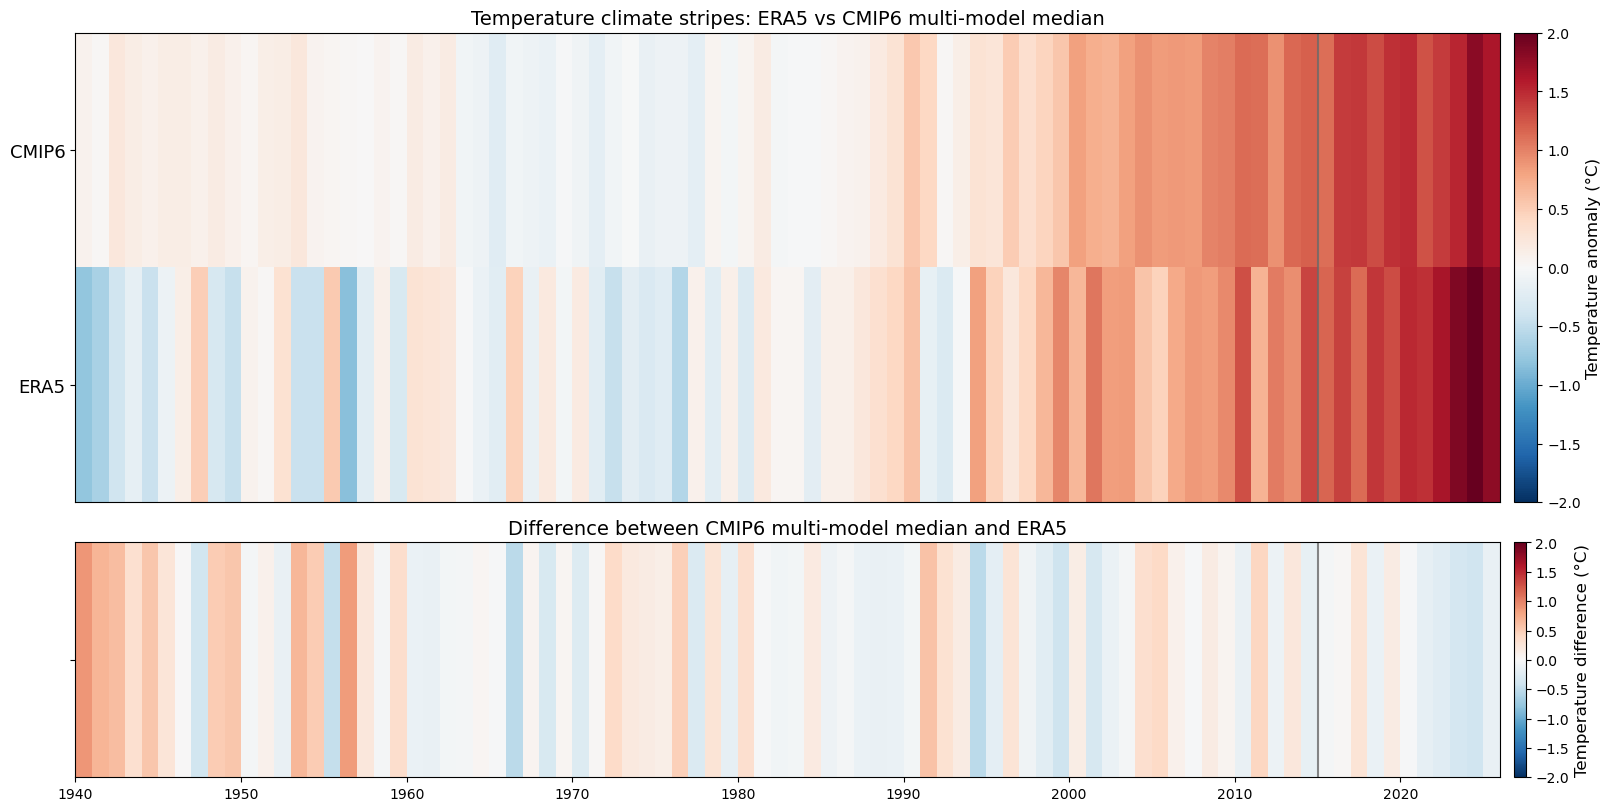

In [102]:
# Plot climate stripes and CMIP6 - ERA5 difference

fig, axs = plt.subplots(
    2,
    1,
    figsize=(16, 8),
    gridspec_kw={
        "height_ratios": [2, 1]
    },
    constrained_layout=True
)

# TOP PANEL: ERA5 and CMIP6 multi-model median climate stripes

# Create a 2-row array
stripe_data = np.vstack([
    Z.transpose(),
    t_anom_median_period.data
])

# Common temperature anomaly scale
vmin = -2
vmax = 2

cmap = plt.get_cmap("RdBu_r")

img = axs[0].pcolormesh(
    time,
    np.arange(3),
    stripe_data,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    shading="flat"
)

# Labels
axs[0].set_yticks([0.5, 1.5])
axs[0].set_yticklabels([
    "ERA5",
    "CMIP6"
], fontsize = 13)

axs[0].set_xticks([])

axs[0].set_title(
    "Temperature climate stripes: ERA5 vs CMIP6 multi-model median",
    fontsize=14
)

# Colorbar
cbar = fig.colorbar(
    img,
    ax=axs[0],
    orientation="vertical",
    pad=0.01
)

cbar.set_label("Temperature anomaly (°C)", fontsize = 12)


# BOTTOM PANEL: CMIP6 multi-model median - ERA5

diff_vmax = np.nanmax(np.abs(diff_values))

diff_img = axs[1].pcolormesh(
    time,
    [0, 1],
    diff_values,
    cmap=plt.get_cmap("RdBu_r"),
    vmin=vmin,
    vmax=vmax,
    shading="flat"
)

axs[1].set_yticks([0.5])
axs[1].set_yticklabels([
    ""
], fontsize = 13)

axs[1].set_title(
    "Difference between CMIP6 multi-model median and ERA5",
    fontsize=14
)

# Colorbar
cbar_diff = fig.colorbar(
    diff_img,
    ax=axs[1],
    orientation="vertical",
    pad=0.01
)

cbar_diff.set_label("Temperature difference (°C)", fontsize = 12)

axs[0].axvline(x=2015, color='dimgrey', linewidth=1.5, linestyle="-", alpha=0.8)
axs[1].axvline(x=2015, color='dimgrey', linewidth=1.5, linestyle="-", alpha=0.8)

plt.show()

As shown in the figure, the historical CMIP6 multi-model ensemble median reproduces the long-term evolution of the ERA5 temperature record remarkably well. As expected, the ensemble median exhibits substantially lower interannual variability than ERA5, since averaging across multiple climate models tends to smooth out the effects of individual years of internal climate variability. Nevertheless, the ensemble median provides an excellent representation of the observed long-term warming trend, particularly over the historical period.

An interesting feature emerges during the projection period, beginning in 2015. Although the CMIP6 simulations are no longer constrained by the actual year-to-year evolution of the climate system, the ensemble median continues to closely track the ERA5 record during the first decade of the projection period. In particular, the projected warming trajectory remains broadly consistent with the recent warming observed in the reanalysis. The exceptional warmth recorded in the Mediterranean region in 2024 is also consistent with the range of outcomes represented by the CMIP6 ensemble, while the ensemble median continues to capture the broader increase in global temperatures observed in recent years.